# Time Travel  

Allows going back to a checkpoint and then re-doing entire execution from that node  
Helps in debugging

In [27]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langgraph.graph.message import add_messages

from langgraph.checkpoint.memory import InMemorySaver

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing import Literal, TypedDict, Annotated

load_dotenv()

True

In [28]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    max_tokens=1024
)

In [29]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [30]:
def generate_joke(state: JokeState) -> dict:

    topic = state["topic"]

    joke = llm.invoke(f"Create a funny joke on the topic: {topic}").content

    return {"joke": joke}

In [50]:
def explain_joke(state: JokeState) -> dict:

    joke = state["joke"]

    explanation = llm.invoke(f"Explain the following joke in short: {joke}").content

    return {"explanation": explanation}

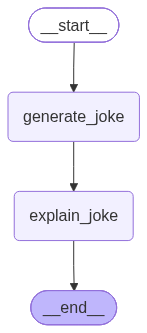

In [58]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("explain_joke", explain_joke)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "explain_joke")
graph.add_edge("explain_joke", END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [59]:
config1 = {
    "configurable":{
        "thread_id": "1"
    }
}

output_state = workflow.invoke({"topic": "Quantum Physics"}, config=config1)
output_state

{'topic': 'Quantum Physics',
 'joke': 'Why did Schrödinger’s cat join a dating app?  \nBecause it wanted to find out if it was single *or* in a relationship—before it even opened the app, it was already in a super‑position of “purr‑fect” and “not yet!”',
 'explanation': 'The joke mixes a quantum‑physics thought experiment with dating humor.  \nSchrödinger’s cat is famously in a super‑position of “alive” and “dead” until you look.  \nIn the joke the cat is already in a super‑position of “single” and “in a relationship” before it even opens a dating app—so its status is “purr‑fect” or not, all at once, until the app forces a measurement (a decision). The humor comes from applying the absurd quantum idea to a relatable situation and the pun on “purr‑fect.”'}

In [60]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'Quantum Physics', 'joke': 'Why did Schrödinger’s cat join a dating app?  \nBecause it wanted to find out if it was single *or* in a relationship—before it even opened the app, it was already in a super‑position of “purr‑fect” and “not yet!”', 'explanation': 'The joke mixes a quantum‑physics thought experiment with dating humor.  \nSchrödinger’s cat is famously in a super‑position of “alive” and “dead” until you look.  \nIn the joke the cat is already in a super‑position of “single” and “in a relationship” before it even opens a dating app—so its status is “purr‑fect” or not, all at once, until the app forces a measurement (a decision). The humor comes from applying the absurd quantum idea to a relatable situation and the pun on “purr‑fect.”'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a0615-996f-6e63-8002-b7cda58f7a68'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-25T08:

In [61]:
checkpoint_config = {
    "configurable": {
        "thread_id": "1",
        "checkpoint_id": '1f1a0615-86e2-6320-8000-f8dad51529c3'
    }
}

state = workflow.get_state(config=checkpoint_config)
state

StateSnapshot(values={'topic': 'Quantum Physics'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1a0615-86e2-6320-8000-f8dad51529c3'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-25T08:45:38.108066+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a0615-86dd-6da9-bfff-fd20ae3692c0'}}, tasks=(PregelTask(id='3e6707ed-3baa-a95b-79bd-bf16b6d1411c', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did Schrödinger’s cat join a dating app?  \nBecause it wanted to find out if it was single *or* in a relationship—before it even opened the app, it was already in a super‑position of “purr‑fect” and “not yet!”'}),), interrupts=())

In [63]:
workflow.invoke(state.values, config = config1)

{'topic': 'Quantum Physics',
 'joke': '**Joke:**  \n*Schrödinger’s cat walks into a bar. The bartender says, “We don’t serve cats.” The cat replies, “I’m not sure if I’m dead or alive, but I’m definitely here!”*',
 'explanation': '**Short explanation:**  \nThe joke riffs on Schrödinger’s famous quantum thought experiment, where a cat in a sealed box is simultaneously dead and alive until someone looks. The bartender’s “we don’t serve cats” is a literal bar rule, while the cat’s reply (“I’m not sure if I’m dead or alive, but I’m definitely here!”) jokes that being *here* means it must be alive, resolving the paradox in a punchline.'}

In [64]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'Quantum Physics', 'joke': '**Joke:**  \n*Schrödinger’s cat walks into a bar. The bartender says, “We don’t serve cats.” The cat replies, “I’m not sure if I’m dead or alive, but I’m definitely here!”*', 'explanation': '**Short explanation:**  \nThe joke riffs on Schrödinger’s famous quantum thought experiment, where a cat in a sealed box is simultaneously dead and alive until someone looks. The bartender’s “we don’t serve cats” is a literal bar rule, while the cat’s reply (“I’m not sure if I’m dead or alive, but I’m definitely here!”) jokes that being *here* means it must be alive, resolving the paradox in a punchline.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a0619-273a-6991-8006-ac4995402cc5'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-08-25T08:47:15.452130+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a0619-219d-6

Updating state value from a particular checkpoint

In [65]:
workflow.update_state({
    "configurable": {
        "thread_id": "1",
        "checkpoint_id": '1f1a0615-86e2-6320-8000-f8dad51529c3',
        "checkpoint_ns": ""
    }
}, {"topic": "AI"})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1a061b-2b87-6cad-8001-b7c570cd4c37'}}

In [66]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'AI'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a061b-2b87-6cad-8001-b7c570cd4c37'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-25T08:48:09.590212+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a0615-86e2-6320-8000-f8dad51529c3'}}, tasks=(PregelTask(id='1a77bf0e-c4ab-554d-2f51-039cfbc1d5b2', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'Quantum Physics', 'joke': '**Joke:**  \n*Schrödinger’s cat walks into a bar. The bartender says, “We don’t serve cats.” The cat replies, “I’m not sure if I’m dead or alive, but I’m definitely here!”*', 'explanation': '**Short explanation:**  \nThe joke riffs on Schrödinger’s famous quantum thought experiment, where a cat in a sealed box is simultane

In [67]:
workflow.invoke(None, config=config1)

{'topic': 'AI',
 'joke': 'Why did the AI go to the comedy club?\n\nBecause it heard the humans were *laughing* at *its* code! 😂',
 'explanation': '**Short explanation:**  \nThe joke hinges on a double‑meaning pun.  \n- “Humans were *laughing* at *its* code” sounds like the humans are amused by the AI’s programming.  \n- But the joke flips it: the AI thinks humans are laughing *at* its code, when actually they’re just laughing at the AI itself.  \n\nSo the AI goes to a comedy club because it thinks the humans’ jokes are all about its code—only to discover the humans are simply laughing at the AI.'}